Running comprehensive DC offset analysis...

Plots for 21.58 MHz


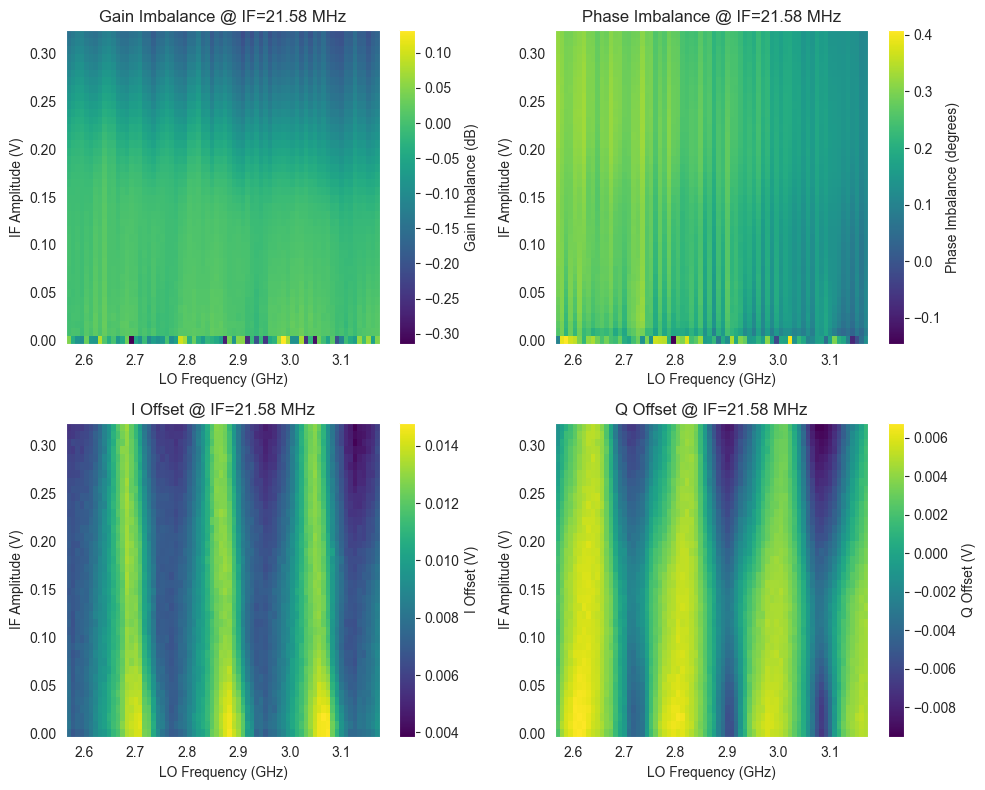


Plots for 23.738 MHz


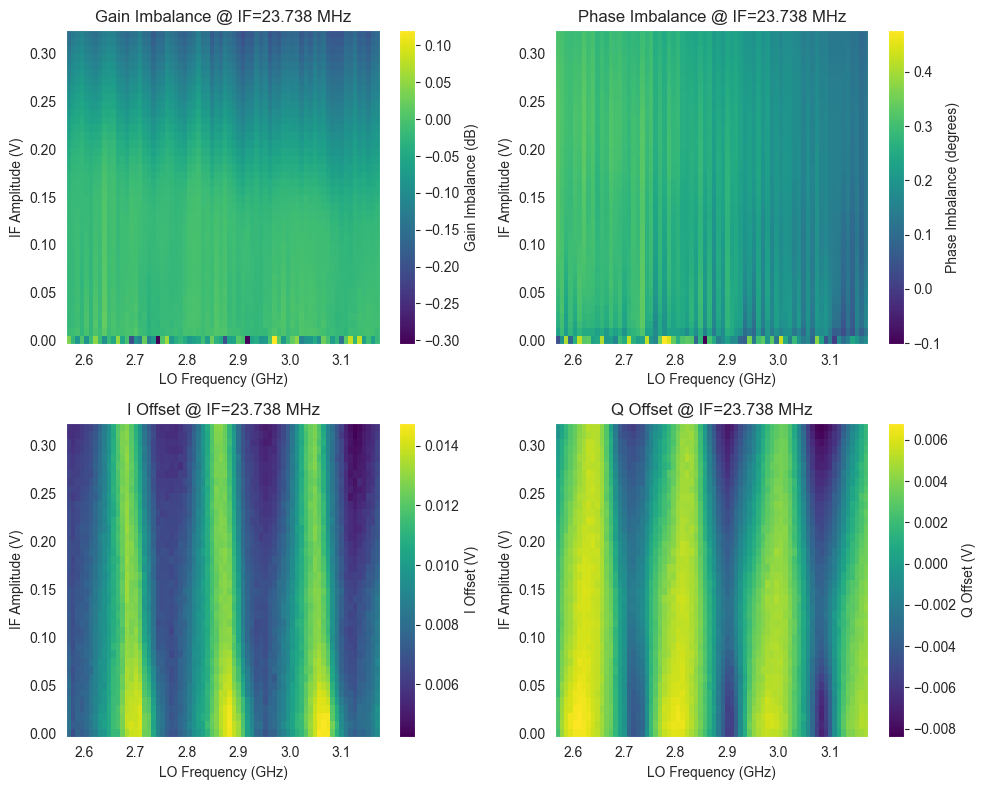


Plots for 19.422 MHz


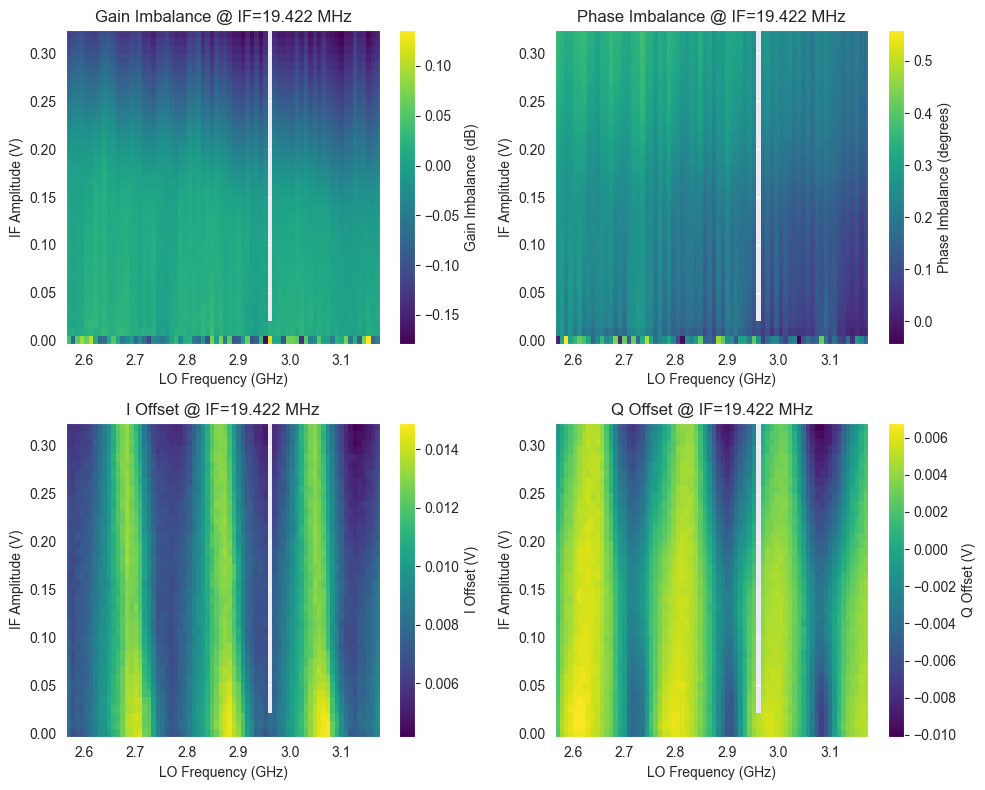


Analyzing DC offset dependency on IF frequency...


C:\Users\aj92uwef\AppData\Local\Temp\ipykernel_30876\3072563147.py:79: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


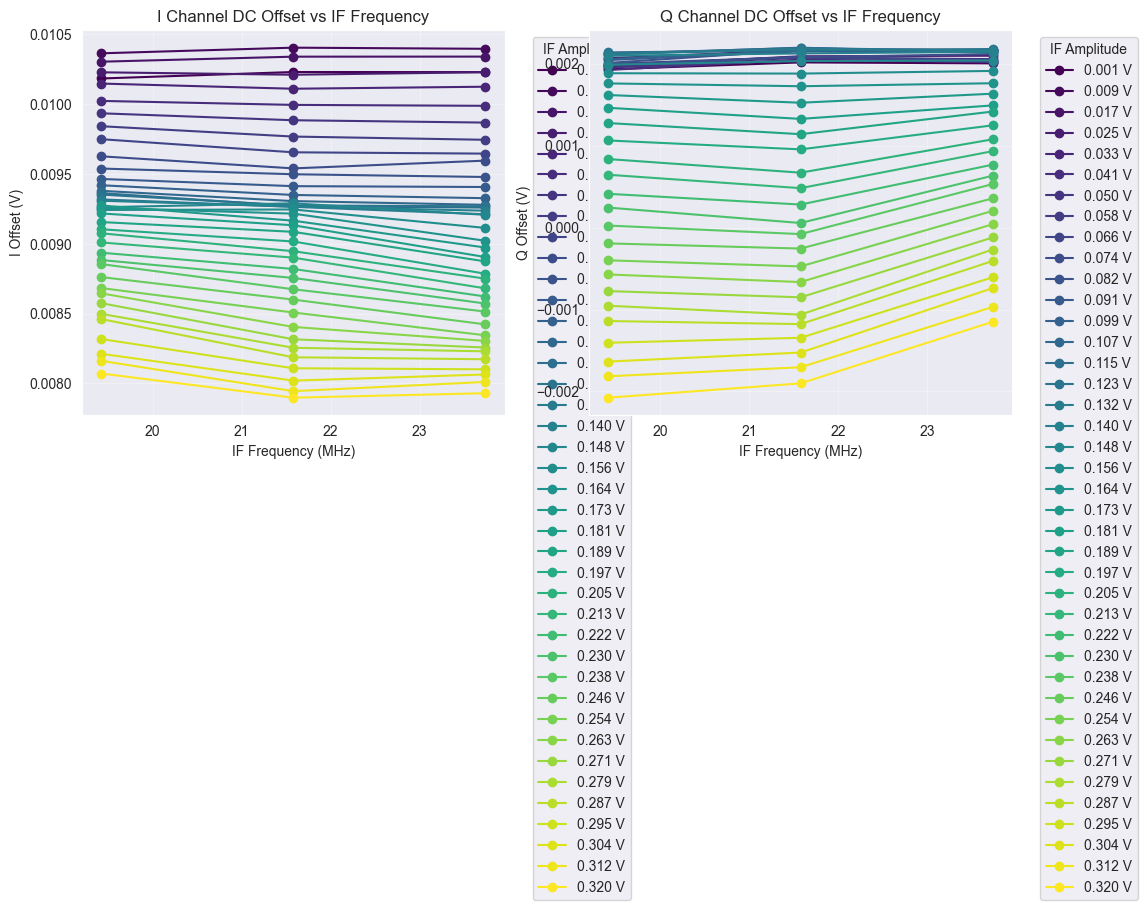


Creating 3D surface plots...


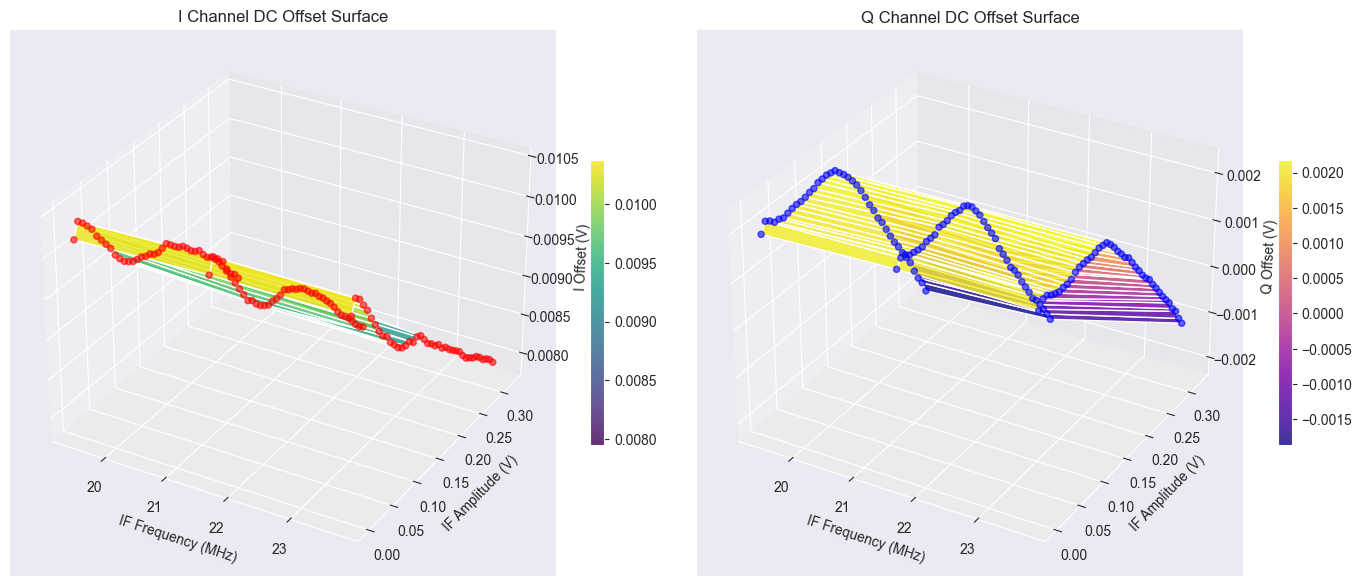


Creating contour plots...


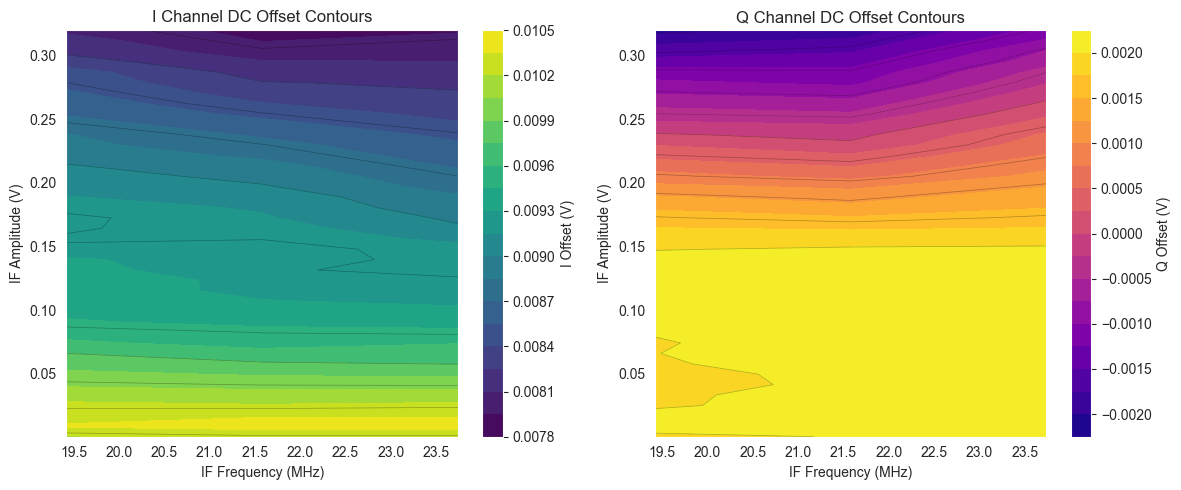


Performing statistical analysis...


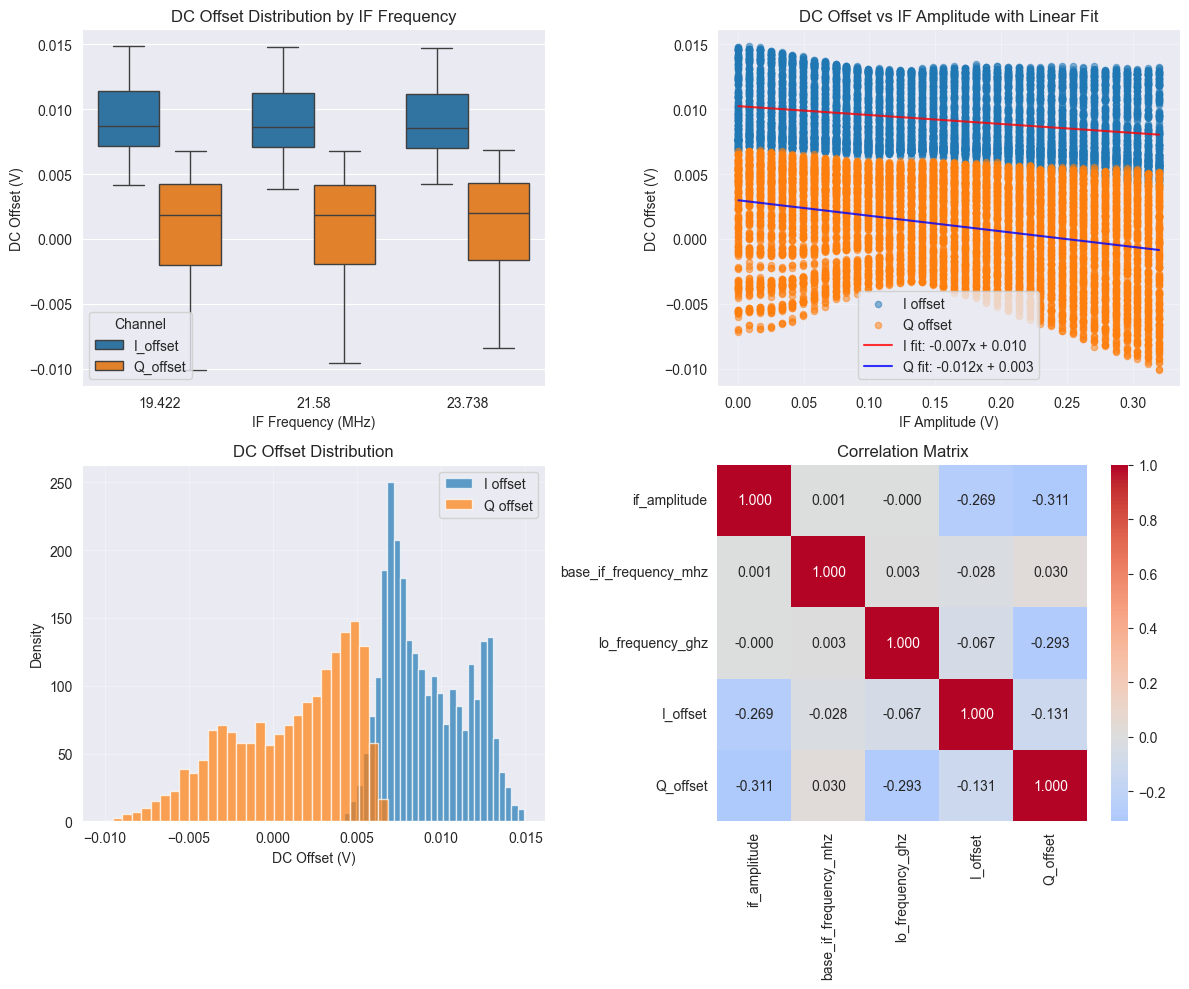


=== DC Offset Summary Statistics ===

Overall statistics:
          I_offset     Q_offset
count  8363.000000  8363.000000
mean      0.009142     0.001066
std       0.002420     0.003652
min       0.003847    -0.010097
25%       0.007095    -0.001853
50%       0.008621     0.001877
75%       0.011279     0.004247
max       0.014908     0.006823

Statistics by IF frequency:
                       I_offset            Q_offset          
                           mean       std      mean       std
base_if_frequency_mhz                                        
19.422                 0.009232  0.002420  0.000972  0.003757
21.580                 0.009132  0.002412  0.000980  0.003700
23.738                 0.009063  0.002427  0.001243  0.003489

Statistics by IF amplitude range:
                   I_offset            Q_offset          
                       mean       std      mean       std
amp_range                                                
(0.00018, 0.0644]  0.010121  0.002359  0.00

C:\Users\aj92uwef\AppData\Local\Temp\ipykernel_30876\3072563147.py:265: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_by_amp = df.groupby('amp_range')[['I_offset', 'Q_offset']].agg(['mean', 'std'])


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import seaborn as sns

# Read the data
df = pd.read_csv("calibration_redpitaya_GRAND_SUMMARY_all_IFs.csv", sep="\t")

# Create sub-dataframes for each IF frequency
sub_dfs = {
    freq: df[df['base_if_frequency_mhz'] == freq].drop("base_if_frequency_mhz", axis=1)
    for freq in df['base_if_frequency_mhz'].unique()
}

# Your original 2D plot function
def plot_calibration_parameters_2d(df, if_freq):
    params = ['g', 'phi', 'I_offset', 'Q_offset']
    titles = ['Gain Imbalance', 'Phase Imbalance', 'I Offset', 'Q Offset']
    units = ['dB', 'degrees', 'V', 'V']

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.flatten()

    for i, (param, title, unit) in enumerate(zip(params, titles, units)):
        pivot_data = df.pivot_table(index='if_amplitude', columns='lo_frequency_ghz', values=param)

        im = axs[i].pcolormesh(pivot_data.columns, pivot_data.index, pivot_data.values,
                               shading='auto', cmap='viridis')

        cbar = fig.colorbar(im, ax=axs[i])
        cbar.set_label(f'{title} ({unit})')

        axs[i].set_xlabel('LO Frequency (GHz)')
        axs[i].set_ylabel('IF Amplitude (V)')
        axs[i].set_title(f'{title} @ IF={if_freq} MHz')

    plt.tight_layout()
    plt.savefig(f'calibration_parameters_2d_IF_{if_freq}MHz.pdf')
    plt.show()

# New function: DC offset analysis across all IF frequencies
def plot_dc_offset_vs_if_frequency(df):
    """Plot how DC offsets depend on IF frequency for different IF amplitudes"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Group by IF frequency and IF amplitude, taking mean across LO frequencies
    grouped = df.groupby(['base_if_frequency_mhz', 'if_amplitude'])[['I_offset', 'Q_offset']].mean().reset_index()

    # Get unique IF amplitudes for color coding
    if_amps = sorted(grouped['if_amplitude'].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(if_amps)))

    # Plot I_offset
    for i, amp in enumerate(if_amps):
        data = grouped[grouped['if_amplitude'] == amp]
        ax1.plot(data['base_if_frequency_mhz'], data['I_offset'],
                'o-', color=colors[i], label=f'{amp:.3f} V', markersize=6)

    ax1.set_xlabel('IF Frequency (MHz)')
    ax1.set_ylabel('I Offset (V)')
    ax1.set_title('I Channel DC Offset vs IF Frequency')
    ax1.grid(True, alpha=0.3)
    ax1.legend(title='IF Amplitude', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot Q_offset
    for i, amp in enumerate(if_amps):
        data = grouped[grouped['if_amplitude'] == amp]
        ax2.plot(data['base_if_frequency_mhz'], data['Q_offset'],
                'o-', color=colors[i], label=f'{amp:.3f} V', markersize=6)

    ax2.set_xlabel('IF Frequency (MHz)')
    ax2.set_ylabel('Q Offset (V)')
    ax2.set_title('Q Channel DC Offset vs IF Frequency')
    ax2.grid(True, alpha=0.3)
    ax2.legend(title='IF Amplitude', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('dc_offset_vs_if_frequency.pdf')
    plt.show()

# New function: 3D surface plots for DC offsets
def plot_dc_offset_3d_surface(df):
    """Create 3D surface plots showing DC offset dependency on IF amplitude and frequency"""
    fig = plt.figure(figsize=(14, 6))

    # Prepare data - average across LO frequencies
    grouped = df.groupby(['base_if_frequency_mhz', 'if_amplitude'])[['I_offset', 'Q_offset']].mean().reset_index()

    # Create meshgrid for interpolation
    if_freq_unique = np.sort(grouped['base_if_frequency_mhz'].unique())
    if_amp_unique = np.sort(grouped['if_amplitude'].unique())
    IF_FREQ, IF_AMP = np.meshgrid(if_freq_unique, if_amp_unique)

    # Interpolate I_offset
    ax1 = fig.add_subplot(121, projection='3d')
    I_offset_interp = griddata(
        (grouped['base_if_frequency_mhz'], grouped['if_amplitude']),
        grouped['I_offset'],
        (IF_FREQ, IF_AMP),
        method='cubic'
    )

    surf1 = ax1.plot_surface(IF_FREQ, IF_AMP, I_offset_interp, cmap='viridis', alpha=0.8)
    ax1.scatter(grouped['base_if_frequency_mhz'], grouped['if_amplitude'], grouped['I_offset'],
                c='red', s=20, alpha=0.6)

    ax1.set_xlabel('IF Frequency (MHz)')
    ax1.set_ylabel('IF Amplitude (V)')
    ax1.set_zlabel('I Offset (V)')
    ax1.set_title('I Channel DC Offset Surface')
    fig.colorbar(surf1, ax=ax1, shrink=0.5)

    # Interpolate Q_offset
    ax2 = fig.add_subplot(122, projection='3d')
    Q_offset_interp = griddata(
        (grouped['base_if_frequency_mhz'], grouped['if_amplitude']),
        grouped['Q_offset'],
        (IF_FREQ, IF_AMP),
        method='cubic'
    )

    surf2 = ax2.plot_surface(IF_FREQ, IF_AMP, Q_offset_interp, cmap='plasma', alpha=0.8)
    ax2.scatter(grouped['base_if_frequency_mhz'], grouped['if_amplitude'], grouped['Q_offset'],
                c='blue', s=20, alpha=0.6)

    ax2.set_xlabel('IF Frequency (MHz)')
    ax2.set_ylabel('IF Amplitude (V)')
    ax2.set_zlabel('Q Offset (V)')
    ax2.set_title('Q Channel DC Offset Surface')
    fig.colorbar(surf2, ax=ax2, shrink=0.5)

    plt.tight_layout()
    plt.savefig('dc_offset_3d_surface.pdf')
    plt.show()

# New function: Contour plots for DC offsets
def plot_dc_offset_contours(df):
    """Create contour plots for DC offsets as function of IF frequency and amplitude"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Average across LO frequencies
    grouped = df.groupby(['base_if_frequency_mhz', 'if_amplitude'])[['I_offset', 'Q_offset']].mean().reset_index()

    # Create pivot tables
    I_pivot = grouped.pivot_table(index='if_amplitude', columns='base_if_frequency_mhz', values='I_offset')
    Q_pivot = grouped.pivot_table(index='if_amplitude', columns='base_if_frequency_mhz', values='Q_offset')

    # I offset contour
    contour1 = ax1.contourf(I_pivot.columns, I_pivot.index, I_pivot.values, levels=20, cmap='viridis')
    ax1.contour(I_pivot.columns, I_pivot.index, I_pivot.values, levels=10, colors='black', alpha=0.3, linewidths=0.5)
    fig.colorbar(contour1, ax=ax1, label='I Offset (V)')

    ax1.set_xlabel('IF Frequency (MHz)')
    ax1.set_ylabel('IF Amplitude (V)')
    ax1.set_title('I Channel DC Offset Contours')

    # Q offset contour
    contour2 = ax2.contourf(Q_pivot.columns, Q_pivot.index, Q_pivot.values, levels=20, cmap='plasma')
    ax2.contour(Q_pivot.columns, Q_pivot.index, Q_pivot.values, levels=10, colors='black', alpha=0.3, linewidths=0.5)
    fig.colorbar(contour2, ax=ax2, label='Q Offset (V)')

    ax2.set_xlabel('IF Frequency (MHz)')
    ax2.set_ylabel('IF Amplitude (V)')
    ax2.set_title('Q Channel DC Offset Contours')

    plt.tight_layout()
    plt.savefig('dc_offset_contours.pdf')
    plt.show()

# New function: Statistical analysis of DC offsets
def plot_dc_offset_statistics(df):
    """Plot statistical analysis of DC offsets"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Box plots by IF frequency
    ax1 = axes[0, 0]
    df_melted = df.melt(id_vars=['base_if_frequency_mhz'],
                        value_vars=['I_offset', 'Q_offset'],
                        var_name='Channel', value_name='DC Offset')
    sns.boxplot(data=df_melted, x='base_if_frequency_mhz', y='DC Offset', hue='Channel', ax=ax1)
    ax1.set_xlabel('IF Frequency (MHz)')
    ax1.set_ylabel('DC Offset (V)')
    ax1.set_title('DC Offset Distribution by IF Frequency')
    ax1.legend(title='Channel')

    # 2. Scatter plot with regression
    ax2 = axes[0, 1]
    ax2.scatter(df['if_amplitude'], df['I_offset'], alpha=0.5, label='I offset', s=20)
    ax2.scatter(df['if_amplitude'], df['Q_offset'], alpha=0.5, label='Q offset', s=20)

    # Add regression lines
    z_i = np.polyfit(df['if_amplitude'], df['I_offset'], 1)
    z_q = np.polyfit(df['if_amplitude'], df['Q_offset'], 1)
    p_i = np.poly1d(z_i)
    p_q = np.poly1d(z_q)

    amp_range = np.linspace(df['if_amplitude'].min(), df['if_amplitude'].max(), 100)
    ax2.plot(amp_range, p_i(amp_range), 'r-', alpha=0.8, label=f'I fit: {z_i[0]:.3f}x + {z_i[1]:.3f}')
    ax2.plot(amp_range, p_q(amp_range), 'b-', alpha=0.8, label=f'Q fit: {z_q[0]:.3f}x + {z_q[1]:.3f}')

    ax2.set_xlabel('IF Amplitude (V)')
    ax2.set_ylabel('DC Offset (V)')
    ax2.set_title('DC Offset vs IF Amplitude with Linear Fit')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Histogram of offsets
    ax3 = axes[1, 0]
    ax3.hist(df['I_offset'], bins=30, alpha=0.7, label='I offset', density=True)
    ax3.hist(df['Q_offset'], bins=30, alpha=0.7, label='Q offset', density=True)
    ax3.set_xlabel('DC Offset (V)')
    ax3.set_ylabel('Density')
    ax3.set_title('DC Offset Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Correlation heatmap
    ax4 = axes[1, 1]
    corr_vars = ['if_amplitude', 'base_if_frequency_mhz', 'lo_frequency_ghz', 'I_offset', 'Q_offset']
    corr_matrix = df[corr_vars].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax4)
    ax4.set_title('Correlation Matrix')

    plt.tight_layout()
    plt.savefig('dc_offset_statistics.pdf')
    plt.show()

# Run all analyses
print("Running comprehensive DC offset analysis...")

# 1. Original 2D plots for each IF frequency
for key, sub_df in sub_dfs.items():
    print(f"\nPlots for {key} MHz")
    plot_calibration_parameters_2d(sub_df, key)

# 2. DC offset vs IF frequency analysis
print("\nAnalyzing DC offset dependency on IF frequency...")
plot_dc_offset_vs_if_frequency(df)

# 3. 3D surface plots
print("\nCreating 3D surface plots...")
plot_dc_offset_3d_surface(df)

# 4. Contour plots
print("\nCreating contour plots...")
plot_dc_offset_contours(df)

# 5. Statistical analysis
print("\nPerforming statistical analysis...")
plot_dc_offset_statistics(df)

# Summary statistics
print("\n=== DC Offset Summary Statistics ===")
print("\nOverall statistics:")
print(df[['I_offset', 'Q_offset']].describe())

print("\nStatistics by IF frequency:")
stats_by_freq = df.groupby('base_if_frequency_mhz')[['I_offset', 'Q_offset']].agg(['mean', 'std'])
print(stats_by_freq)

print("\nStatistics by IF amplitude range:")
df['amp_range'] = pd.cut(df['if_amplitude'], bins=5)
stats_by_amp = df.groupby('amp_range')[['I_offset', 'Q_offset']].agg(['mean', 'std'])
print(stats_by_amp)

# Dependence of optimal DC-offsets on IF-frequency and IF-amplitude